## **agentic ai - assignment alpha (q4)**

### **23K-0074**

### **eco-friendly agents**

every agent below is built to use as little compute and real world resources as possible, and its CO2 and water footprint is measured with the equations from the *how hungry is ai* paper:

- energy (kWh) = runtime (h) x power (kW) x PUE
- water (L) = (energy / PUE) x WUE_site + energy x WUE_source
- carbon (kg CO2e) = energy x CIF

PUE, WUE and CIF values are taken from table 1 of the paper (microsoft azure row). each agent is compared against a baseline version that does the same job without the eco design, so the saving is visible.

In [1]:
import time
import numpy as np

#environmental multipliers from table 1 of "how hungry is ai" (azure)
PUE = 1.12
WUE_SITE = 0.30      #L/kWh
WUE_SOURCE = 3.142   #L/kWh
CIF = 0.3528         #kgCO2e/kWh

#assumed edge device the agents run on (laptop class cpu)
DEVICE_POWER_W = 15

def footprint_from_energy(energy_kwh):
    water_l = (energy_kwh / PUE) * WUE_SITE + energy_kwh * WUE_SOURCE
    carbon_kg = energy_kwh * CIF
    return water_l, carbon_kg

def footprint_from_runtime(seconds, power_w=DEVICE_POWER_W):
    energy_kwh = (seconds / 3600) * (power_w / 1000) * PUE
    water_l, carbon_kg = footprint_from_energy(energy_kwh)
    return energy_kwh, water_l, carbon_kg

def measure(fn, repeats=5):
    #min of a few runs to reduce timing noise
    best = float("inf")
    result = None
    for _ in range(repeats):
        start = time.perf_counter()
        result = fn()
        best = min(best, time.perf_counter() - start)
    return best, result

def report(name, seconds, scale=1):
    e, w, c = footprint_from_runtime(seconds * scale)
    print(f"{name}, runtime={seconds*1000:.3f} ms | energy={e:.3e} kWh | water={w*1000:.4f} mL | CO2={c*1e6:.4f} mg")
    return e, w, c

#sanity check: 1 kWh -> water and carbon
print("1 kWh ->", [round(x, 4) for x in footprint_from_energy(1)], "(L, kgCO2e)")

1 kWh -> [3.4099, 0.3528] (L, kgCO2e)


### **A - reflex agent for abnormal movements in a crowd**

**PEAS**
- performance: detect overcrowding, running and scattering as soon as they happen, few false alarms, low energy per frame
- environment: a 50 x 50 m public area (stadium gate, market) with 200 people
- actuators: alerts to security, open extra exits, keep monitoring
- sensors: overhead camera that gives each person's position and velocity per frame

**agent type:** simple reflex. it only looks at the current frame (percept) and fires the first matching condition-action rule, no memory of past frames.

**rules (checked in order)**
1. max local density > 4 people/m2 -> overcrowding: open extra exits
2. mean speed > 2.5 m/s -> running: alert security
3. direction spread > 0.6 and mean speed > 1.5 m/s -> scattering: alert security
4. otherwise -> normal: keep monitoring

**eco design**
- baseline computes density with all pairwise distances, O(n^2) per frame, on every frame (25 fps)
- eco agent computes density with a 2 x 2 m grid histogram, O(n), and the camera sends every 2nd frame (12.5 fps). abnormal events last over a second so nothing is missed
- no deep model, only numpy on the edge device, so no data center or upload cost

In [2]:
import numpy as np

rng = np.random.default_rng(42)
N, T, AREA, FPS = 200, 300, 50.0, 25

#simulated crowd: normal walking, panic running away from a point (frames 150-179),
#sudden surge where 80 people crowd into a 3 m radius (frames 240-259)
pos = rng.uniform(0, AREA, (N, 2))
frames = []
truth = []
for t in range(T):
    ang = rng.normal(0, 0.3, N)
    speed = rng.normal(1.2, 0.2, N).clip(0.3)
    vel = np.c_[np.cos(ang), np.sin(ang)] * speed[:, None]
    label = "normal"
    if 150 <= t < 180:
        away = pos - np.array([25, 25])
        away /= np.linalg.norm(away, axis=1, keepdims=True) + 1e-9
        vel = away * rng.normal(4.0, 0.5, N)[:, None]
        label = "panic"
    pos = (pos + vel / FPS) % AREA
    p = pos.copy()
    if 240 <= t < 260:
        r = rng.uniform(0, 3, 80)
        th = rng.uniform(0, 2 * np.pi, 80)
        p[:80] = np.c_[25 + r * np.cos(th), 25 + r * np.sin(th)]
        label = "surge"
    frames.append((p, vel))
    truth.append(label)

print("frames:", len(frames), "| people:", N)
print("ground truth counts:", {k: truth.count(k) for k in set(truth)})

frames: 300 | people: 200
ground truth counts: {'surge': 20, 'panic': 30, 'normal': 250}


In [3]:
import numpy as np

def density_pairwise(p):
    #baseline: neighbours within 1 m for every person -> O(n^2)
    d = np.linalg.norm(p[:, None, :] - p[None, :, :], axis=2)
    return ((d < 1.0).sum(axis=1) - 1).max() / np.pi

def density_grid(p):
    #eco: count people per 2x2 m cell -> O(n)
    h, _, _ = np.histogram2d(p[:, 0], p[:, 1], bins=25, range=[[0, AREA], [0, AREA]])
    return h.max() / 4.0

def reflex_agent(percept, density_fn):
    p, v = percept
    speed = np.linalg.norm(v, axis=1)
    mean_speed = speed.mean()
    unit = v / (speed[:, None] + 1e-9)
    spread = 1 - np.linalg.norm(unit.mean(axis=0))
    density = density_fn(p)

    if density > 4:
        return "overcrowding: open extra exits"
    if mean_speed > 2.5:
        return "running: alert security"
    if spread > 0.6 and mean_speed > 1.5:
        return "scattering: alert security"
    return "normal: keep monitoring"

for t in [10, 160, 250]:
    print(f"frame {t} ({truth[t]}) -> {reflex_agent(frames[t], density_grid)}")

frame 10 (normal) -> normal: keep monitoring
frame 160 (panic) -> running: alert security
frame 250 (surge) -> overcrowding: open extra exits


In [4]:
def run_baseline():
    return [reflex_agent(frames[t], density_pairwise) for t in range(T)]

def run_eco():
    #camera sends every 2nd frame
    return {t: reflex_agent(frames[t], density_grid) for t in range(0, T, 2)}

t_base, actions_base = measure(run_baseline)
t_eco, actions_eco = measure(run_eco)

def is_alert(a):
    return not a.startswith("normal")

#detection check: did each agent raise an alert during each event, and any false alarms
for name, acts in [("baseline", dict(enumerate(actions_base))), ("eco", actions_eco)]:
    panic = [is_alert(a) for t, a in acts.items() if truth[t] == "panic"]
    surge = [is_alert(a) for t, a in acts.items() if truth[t] == "surge"]
    false = sum(is_alert(a) for t, a in acts.items() if truth[t] == "normal")
    first_panic = min(t for t, a in acts.items() if truth[t] == "panic" and is_alert(a))
    print(f"{name} | frames processed={len(acts)} | panic detected {sum(panic)}/{len(panic)} | surge detected {sum(surge)}/{len(surge)} | false alarms={false} | first panic alert at frame {first_panic}")

baseline | frames processed=300 | panic detected 30/30 | surge detected 20/20 | false alarms=0 | first panic alert at frame 150
eco | frames processed=150 | panic detected 15/15 | surge detected 10/10 | false alarms=0 | first panic alert at frame 150


In [5]:
print("footprint for 12 s of video (300 frames):")
e_b, w_b, c_b = report("baseline", t_base)
e_e, w_e, c_e = report("eco", t_eco)
print(f"\nsaving: {(1 - e_e / e_b) * 100:.1f}% less energy, CO2 and water")

#scaled to one camera running 24/7 for a year (300 frames = 12 s)
scale = 365 * 24 * 3600 / 12
eb, wb, cb = footprint_from_runtime(t_base * scale)
ee, we, ce = footprint_from_runtime(t_eco * scale)
print(f"\nper camera per year -> baseline: {cb:.3f} kg CO2, {wb:.2f} L water | eco: {ce:.3f} kg CO2, {we:.2f} L water")

footprint for 12 s of video (300 frames):
baseline, runtime=218.280 ms | energy=1.019e-06 kWh | water=0.0035 mL | CO2=0.3594 mg
eco, runtime=11.224 ms | energy=5.238e-08 kWh | water=0.0002 mL | CO2=0.0185 mg

saving: 94.9% less energy, CO2 and water

per camera per year -> baseline: 0.944 kg CO2, 9.13 L water | eco: 0.049 kg CO2, 0.47 L water


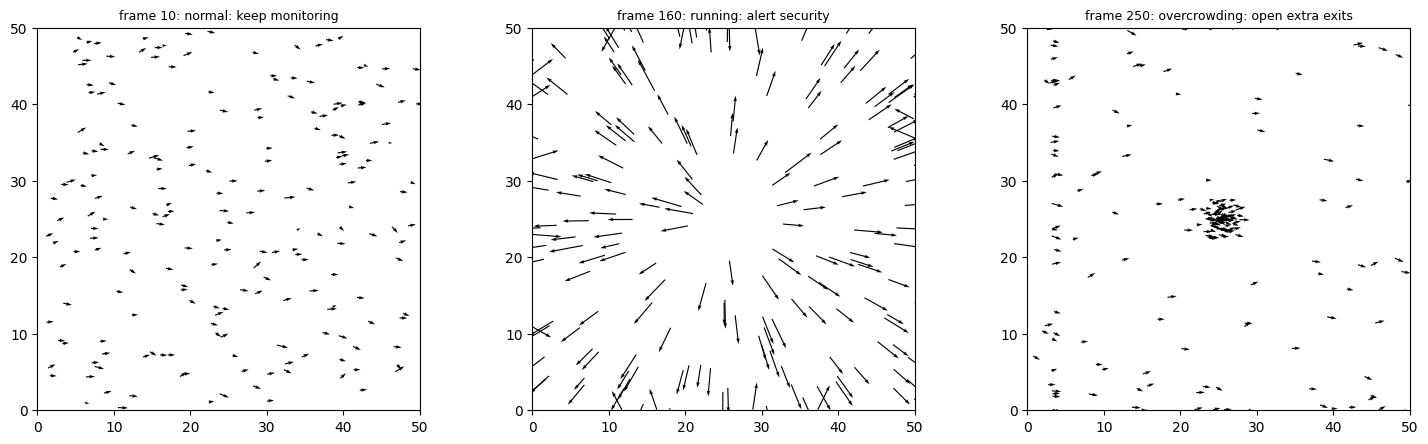

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, t in zip(axes, [10, 160, 250]):
    p, v = frames[t]
    ax.quiver(p[:, 0], p[:, 1], v[:, 0], v[:, 1], angles="xy", scale=60, width=0.003)
    ax.set_xlim(0, AREA)
    ax.set_ylim(0, AREA)
    ax.set_aspect("equal")
    ax.set_title(f"frame {t}: {reflex_agent(frames[t], density_grid)}", fontsize=9)
plt.tight_layout()
plt.show()

### **B - utility-based agent for stressed and tensed patients**

**PEAS**
- performance: reduce patient stress as much as possible, use nurse and doctor time only when needed, low energy per intervention
- environment: hospital ward with patients wearing a wristband, day and night
- actuators: bedside tablet (text prompt, audio, video), nurse call, doctor alert
- sensors: heart rate from wristband, self reported stress (0-10) on the tablet, clock

**agent type:** utility-based. for every patient it computes the expected utility of each action and picks the highest:

U(action) = P(success) x stress reduction x severity weight - staff cost - eco weight x CO2 (g)

- severity weight grows with stress and heart rate, so serious cases value a big reduction more
- if heart rate > 120 bpm, non staff actions only work half as well (a breathing prompt can't fix a panic attack)
- at night, video is less effective since the screen light disturbs sleep

**eco design**
- every action has an energy cost (video on a screen costs much more than a text prompt), turned into CO2 with the paper's CIF
- the eco weight makes the agent pick the low energy action when two actions are close in benefit, but it still calls staff when the case is serious
- compared with the same agent with eco weight = 0

In [7]:
import numpy as np
import pandas as pd

#action: (P(success), stress reduction, energy Wh, staff minutes), energy and success values are assumed
actions = {
    "breathing prompt (text)": (0.70, 2.0, 0.5, 0),
    "calming audio": (0.75, 3.0, 3.0, 0),
    "relaxation video": (0.80, 3.5, 25.0, 0),
    "call nurse": (0.90, 5.0, 0.2, 15),
    "alert doctor": (0.95, 6.0, 0.2, 30),
    "no action": (1.00, 0.0, 0.0, 0)
}

patients = pd.DataFrame({
    "patient": ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"],
    "heart_rate": [82, 95, 128, 101, 88, 135, 76, 110],
    "stress": [3, 6, 9, 7, 5, 9, 2, 8],
    "night": [False, False, True, True, False, False, True, False]
})
print(patients.to_string(index=False))

patient  heart_rate  stress  night
     P1          82       3  False
     P2          95       6  False
     P3         128       9   True
     P4         101       7   True
     P5          88       5  False
     P6         135       9  False
     P7          76       2   True
     P8         110       8  False


In [8]:
import numpy as np
import pandas as pd

STAFF_COST_PER_MIN = 0.15

def expected_utility(patient, action, eco_weight):
    p_success, reduction, energy_wh, staff_min = actions[action]
    critical = patient["heart_rate"] > 120

    if critical and staff_min == 0:
        reduction *= 0.5
    if patient["night"] and action == "relaxation video":
        reduction *= 0.6

    #can't reduce stress below 0
    reduction = min(reduction, patient["stress"])
    severity = 1 + patient["stress"] / 10 + (1 if critical else 0)

    co2_g = footprint_from_energy(energy_wh / 1000)[1] * 1000
    return p_success * reduction * severity - STAFF_COST_PER_MIN * staff_min - eco_weight * co2_g

def utility_agent(patient, eco_weight):
    utils = {a: expected_utility(patient, a, eco_weight) for a in actions}
    return max(utils, key=utils.get), utils

#full utility table for one patient
_, utils = utility_agent(patients.iloc[3], eco_weight=0.5)
print("utilities for P4 (hr 101, stress 7, night):")
for a, u in sorted(utils.items(), key=lambda x: -x[1]):
    print(f"{a} -- U = {u:.3f}")

utilities for P4 (hr 101, stress 7, night):
call nurse -- U = 5.365
alert doctor -- U = 5.155
calming audio -- U = 3.296
breathing prompt (text) -- U = 2.292
no action -- U = 0.000
relaxation video -- U = -1.554


In [9]:
import pandas as pd

rows = []
for _, pt in patients.iterrows():
    for name, w in [("baseline", 0.0), ("eco", 0.5)]:
        action, utils = utility_agent(pt, w)
        p_success, reduction, energy_wh, staff_min = actions[action]
        rows.append([pt["patient"], name, action, round(utils[action], 3), energy_wh, staff_min])

decisions = pd.DataFrame(rows, columns=["patient", "agent", "action", "utility", "energy Wh", "staff min"])
print(decisions.pivot(index="patient", columns="agent", values="action").to_string())

agent            baseline                      eco
patient                                           
P1       relaxation video            calming audio
P2             call nurse               call nurse
P3           alert doctor             alert doctor
P4             call nurse               call nurse
P5             call nurse               call nurse
P6           alert doctor             alert doctor
P7       relaxation video  breathing prompt (text)
P8             call nurse               call nurse


In [11]:
def expected_reduction(pt, action):
    p_success, reduction, _, _ = actions[action]
    if pt["heart_rate"] > 120 and actions[action][3] == 0:
        reduction *= 0.5
    if pt["night"] and action == "relaxation video":
        reduction *= 0.6
    return p_success * min(reduction, pt["stress"])

for name in ["baseline", "eco"]:
    d = decisions[decisions["agent"] == name]
    energy_kwh = d["energy Wh"].sum() / 1000
    water, co2 = footprint_from_energy(energy_kwh)
    red = sum(expected_reduction(patients.iloc[i], a) for i, a in enumerate(d["action"]))
    print(f"{name} | expected stress reduction={red:.2f} | staff min={d['staff min'].sum()} | energy={energy_kwh*1000:.1f} Wh | water={water*1000:.2f} mL | CO2={co2*1000:.2f} g")

#scaled to a 30 bed ward, 6 checks per patient per day, 1 year
scale = 30 / 8 * 6 * 365
for name in ["baseline", "eco"]:
    e = decisions[decisions["agent"] == name]["energy Wh"].sum() / 1000 * scale
    w, c = footprint_from_energy(e)
    print(f"{name} per ward per year -> {c:.2f} kg CO2, {w:.1f} L water")

baseline | expected stress reduction=33.40 | staff min=120 | energy=51.2 Wh | water=174.58 mL | CO2=18.06 g
eco | expected stress reduction=33.05 | staff min=120 | energy=4.7 Wh | water=16.03 mL | CO2=1.66 g
baseline per ward per year -> 148.35 kg CO2, 1433.8 L water
eco per ward per year -> 13.62 kg CO2, 131.6 L water


### **C - goal-based agent for a school van network**

**PEAS**
- performance: every child picked up and dropped at school, only safe roads used, reach school before 7:45, shortest distance (less fuel and CO2)
- environment: road network between the depot, 5 homes and the school, some roads flagged unsafe (unlit, isolated or high crime)
- actuators: route given to the driver, notifications to parents and school
- sensors: road map with distances and safety flags, gps of the van, pickup confirmation (card tap by the child)

**agent type:** goal-based. the goal is a state, not a single action:

goal = (van at school) and (all 5 children on board) and (no unsafe road used) and (arrival before deadline)

the agent searches over states (current location, set of children picked) with uniform cost search, using only safe roads, until it reaches a goal state.

**eco design**
- search cost is distance, so the first goal state found is the shortest safe route -> least fuel
- fuel to CO2: assumed van uses 0.1 L petrol per km, 2.31 kg CO2 per L of petrol burned, about 1.5 L of water per L of petrol to produce (refining), all assumed values
- compared with a baseline that picks children up in a fixed list order

In [12]:
import networkx as nx

#road network: (from, to, km, safe)
roads = [
    ("Depot", "H1", 2.0, True), ("Depot", "H2", 3.5, True), ("Depot", "H3", 2.5, False),
    ("H1", "H2", 1.5, True), ("H1", "H4", 4.0, True), ("H1", "H3", 1.0, False),
    ("H2", "H3", 2.0, True), ("H2", "H5", 2.5, True),
    ("H3", "H4", 1.8, True), ("H3", "School", 3.0, True),
    ("H4", "H5", 1.2, True), ("H4", "School", 2.2, True),
    ("H5", "School", 1.5, False), ("H2", "School", 5.0, True)
]

G = nx.Graph()
for u, v, km, safe in roads:
    G.add_edge(u, v, km=km, safe=safe)

children = {"H1", "H2", "H3", "H4", "H5"}
SPEED_KMH = 30
START_TIME_MIN = 7 * 60
DEADLINE_MIN = 7 * 60 + 45
STOP_MIN = 2

print("unsafe roads:", [(u, v) for u, v, d in G.edges(data=True) if not d["safe"]])

unsafe roads: [('Depot', 'H3'), ('H1', 'H3'), ('H5', 'School')]


In [13]:
import heapq

def goal_test(state, path_edges):
    node, picked = state
    return node == "School" and picked == frozenset(children) and all(G[u][v]["safe"] for u, v in path_edges)

def goal_based_agent(start="Depot"):
    #uniform cost search over (node, picked)
    start_state = (start, frozenset())
    frontier = [(0.0, 0, start_state, [start])]
    explored = set()
    counter = 0
    while frontier:
        cost, _, state, path = heapq.heappop(frontier)
        node, picked = state
        edges = list(zip(path[:-1], path[1:]))
        if goal_test(state, edges):
            return path, cost, len(explored)
        if state in explored:
            continue
        explored.add(state)
        for nxt in G.neighbors(node):
            if not G[node][nxt]["safe"]:
                continue
            #don't enter school until everyone is on board
            if nxt == "School" and picked | ({nxt} & children) != frozenset(children):
                continue
            new_picked = picked | ({nxt} & children)
            counter += 1
            heapq.heappush(frontier, (cost + G[node][nxt]["km"], counter, (nxt, new_picked), path + [nxt]))
    return None, None, len(explored)

route, dist, expanded = goal_based_agent()
print("route:", " -> ".join(route))
print(f"distance: {dist:.1f} km | states expanded: {expanded}")

route: Depot -> H1 -> H2 -> H3 -> H4 -> H5 -> H4 -> School
distance: 11.9 km | states expanded: 56


In [14]:
def simulate_trip(route):
    clock = START_TIME_MIN
    picked = set()
    log = []
    for u, v in zip(route[:-1], route[1:]):
        clock += G[u][v]["km"] / SPEED_KMH * 60
        if v in children and v not in picked:
            picked.add(v)
            clock += STOP_MIN
            log.append(f"{int(clock//60)}:{int(clock%60):02d} - picked child at {v}, parent notified")
    log.append(f"{int(clock//60)}:{int(clock%60):02d} - arrived at school with {len(picked)} children, school notified")
    return clock, log

arrival, log = simulate_trip(route)
for line in log:
    print(line)
print("\ngoal reached:", goal_test((route[-1], frozenset(children & set(route))), list(zip(route[:-1], route[1:]))) and arrival <= DEADLINE_MIN)

7:06 - picked child at H1, parent notified
7:11 - picked child at H2, parent notified
7:17 - picked child at H3, parent notified
7:22 - picked child at H4, parent notified
7:27 - picked child at H5, parent notified
7:33 - arrived at school with 5 children, school notified

goal reached: True


In [15]:
import networkx as nx

#baseline: picks children in the order they registered, each leg on the shortest safe path
safe_G = nx.Graph([(u, v, d) for u, v, d in G.edges(data=True) if d["safe"]])
order = ["Depot", "H4", "H1", "H5", "H3", "H2", "School"]
base_route = ["Depot"]
for a, c in zip(order[:-1], order[1:]):
    base_route += nx.shortest_path(safe_G, a, c, weight="km")[1:]
base_dist = sum(G[u][v]["km"] for u, v in zip(base_route[:-1], base_route[1:]))
print("baseline route:", " -> ".join(base_route))
print(f"baseline distance: {base_dist:.1f} km")

#for reference: the same search if unsafe roads were allowed
unsafe_order_dist = None
best = None
from itertools import permutations
for perm in permutations(sorted(children)):
    stops = ["Depot", *perm, "School"]
    d = sum(nx.shortest_path_length(G, a, c, weight="km") for a, c in zip(stops[:-1], stops[1:]))
    if best is None or d < best[0]:
        best = (d, stops)
print(f"shortest route if unsafe roads were allowed: {best[0]:.1f} km via {' -> '.join(best[1])} (rejected by the goal test)")

baseline route: Depot -> H1 -> H4 -> H1 -> H2 -> H5 -> H4 -> H3 -> H2 -> School
baseline distance: 24.0 km
shortest route if unsafe roads were allowed: 10.0 km via Depot -> H1 -> H2 -> H3 -> H4 -> H5 -> School (rejected by the goal test)


In [16]:
FUEL_L_PER_KM = 0.1
CO2_KG_PER_L = 2.31
WATER_L_PER_L_FUEL = 1.5

for name, d in [("baseline", base_dist), ("goal agent", dist)]:
    fuel = d * FUEL_L_PER_KM
    print(f"{name} | {d:.1f} km | fuel={fuel:.2f} L | CO2={fuel*CO2_KG_PER_L:.3f} kg | water={fuel*WATER_L_PER_L_FUEL:.3f} L")

#2 trips a day, 200 school days
saved_km = (base_dist - dist) * 2 * 200
print(f"\nper van per school year: {saved_km:.0f} km saved -> {saved_km*FUEL_L_PER_KM*CO2_KG_PER_L:.1f} kg CO2 and {saved_km*FUEL_L_PER_KM*WATER_L_PER_L_FUEL:.1f} L water")

t_plan, _ = measure(goal_based_agent)
_ = report("planning", t_plan)

baseline | 24.0 km | fuel=2.40 L | CO2=5.544 kg | water=3.600 L
goal agent | 11.9 km | fuel=1.19 L | CO2=2.749 kg | water=1.785 L

per van per school year: 4840 km saved -> 1118.0 kg CO2 and 726.0 L water
planning, runtime=0.278 ms | energy=1.298e-09 kWh | water=0.0000 mL | CO2=0.0005 mg


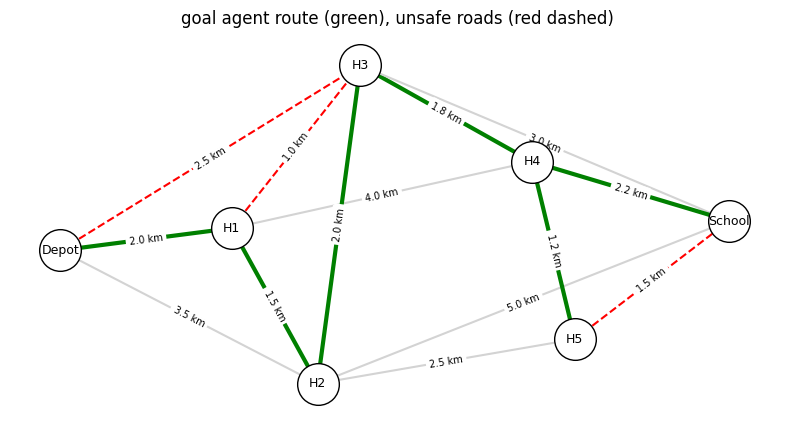

In [17]:
import matplotlib.pyplot as plt
import networkx as nx

layout = {"Depot": (0, 0), "H1": (2, 0.3), "H2": (3, -1.8), "H3": (3.5, 2.5), "H4": (5.5, 1.2), "H5": (6, -1.2), "School": (7.8, 0.4)}
route_edges = set(frozenset(e) for e in zip(route[:-1], route[1:]))

plt.figure(figsize=(10, 5))
for u, v, d in G.edges(data=True):
    color = "green" if frozenset((u, v)) in route_edges else ("red" if not d["safe"] else "lightgray")
    style = "--" if not d["safe"] else "-"
    width = 3 if frozenset((u, v)) in route_edges else 1.5
    nx.draw_networkx_edges(G, layout, edgelist=[(u, v)], edge_color=color, style=style, width=width)
nx.draw_networkx_nodes(G, layout, node_color="white", edgecolors="black", node_size=900)
nx.draw_networkx_labels(G, layout, font_size=9)
nx.draw_networkx_edge_labels(G, layout, edge_labels={(u, v): f"{d['km']} km" for u, v, d in G.edges(data=True)}, font_size=7)
plt.title("goal agent route (green), unsafe roads (red dashed)")
plt.axis("off")
plt.show()

### **D - learning agent to encourage sports activities in young people**

**PEAS**
- performance: weekly participation rate of young people in sports, with low water and energy use per session
- environment: 90 young people in 3 age groups (13-15, 16-18, 19-24), each group has hidden preferences for 6 activities
- actuators: one weekly suggestion message per person (which activity to try this week)
- sensors: check in at the ground/court (did they take part or not)

**agent type:** learning agent, with the 4 components:
- performance element: picks the activity with the highest learned value for the person's age group
- critic: turns the check in into a reward, reward = participated - eco weight x resource cost of the activity
- learning element: updates the value estimate, Q = Q + alpha x (reward - Q)
- problem generator: with probability epsilon suggests a random activity to explore

**eco design**
- the reward includes each activity's water and energy cost (swimming pool top up and heating, indoor court lights and AC), so the agent learns to suggest outdoor low resource sports when people like them about as much
- one message per week, and a tiny Q table instead of a deep recommender model
- water and energy per session are assumed values, energy turned into CO2 and water with the paper's CIF and WUE

In [22]:
import numpy as np

activities = ["running", "cycling", "football", "cricket", "badminton (indoor)", "swimming"]

#per session: (direct water L, energy kWh), assumed values
resources = {
    "running": (0, 0.0),
    "cycling": (0, 0.0),
    "football": (20, 0.1),
    "cricket": (30, 0.1),
    "badminton (indoor)": (5, 1.5),
    "swimming": (200, 2.0)
}

def session_cost(activity):
    water_direct, energy = resources[activity]
    water_energy, co2 = footprint_from_energy(energy)
    return water_direct + water_energy, co2

#normalised resource cost (0 to 1) used in the reward
raw_cost = np.array([session_cost(a)[0] / 250 + session_cost(a)[1] / 0.8 for a in activities])
eco_cost = raw_cost / raw_cost.max()

groups = ["13-15", "16-18", "19-24"]
#hidden probability that a person in each group takes part if suggested each activity
true_p = np.array([
    [0.30, 0.35, 0.60, 0.55, 0.40, 0.62],
    [0.35, 0.40, 0.55, 0.65, 0.50, 0.58],
    [0.50, 0.45, 0.45, 0.40, 0.55, 0.50]
])
PEOPLE_PER_GROUP = 30
WEEKS = 52

for a, c in zip(activities, eco_cost):
    w, co2 = session_cost(a)
    print(f"{a}:\nwater = {w:.2f} L,  CO2 = {co2:.3f} kg,  eco cost = {c:.3f}\n")

running:
water = 0.00 L,  CO2 = 0.000 kg,  eco cost = 0.000

cycling:
water = 0.00 L,  CO2 = 0.000 kg,  eco cost = 0.000

football:
water = 20.34 L,  CO2 = 0.035 kg,  eco cost = 0.073

cricket:
water = 30.34 L,  CO2 = 0.035 kg,  eco cost = 0.097

badminton (indoor):
water = 10.11 L,  CO2 = 0.529 kg,  eco cost = 0.411

swimming:
water = 206.82 L,  CO2 = 0.706 kg,  eco cost = 1.000



In [23]:
import numpy as np

class SportsLearningAgent:
    def __init__(self, eco_weight, epsilon=0.1, alpha=0.1, seed=0):
        self.q = np.zeros((len(groups), len(activities)))
        self.eco_weight = eco_weight
        self.epsilon = epsilon
        self.alpha = alpha
        self.rng = np.random.default_rng(seed)

    def performance_element(self, g):
        return int(np.argmax(self.q[g]))

    def problem_generator(self):
        return int(self.rng.integers(len(activities)))

    def act(self, g):
        if self.rng.random() < self.epsilon:
            return self.problem_generator()
        return self.performance_element(g)

    def critic(self, participated, a):
        return participated - self.eco_weight * eco_cost[a] * participated

    def learning_element(self, g, a, reward):
        self.q[g, a] += self.alpha * (reward - self.q[g, a])

def run(agent=None, seed=1):
    env_rng = np.random.default_rng(seed)
    rate, water, co2 = [], 0.0, 0.0
    for week in range(WEEKS):
        joined = 0
        for g in range(len(groups)):
            for _ in range(PEOPLE_PER_GROUP):
                a = agent.act(g) if agent else int(env_rng.integers(len(activities)))
                participated = int(env_rng.random() < true_p[g, a])
                if agent:
                    agent.learning_element(g, a, agent.critic(participated, a))
                if participated:
                    w, c = session_cost(activities[a])
                    water += w
                    co2 += c
                joined += participated
        rate.append(joined / (len(groups) * PEOPLE_PER_GROUP))
    return np.array(rate), water, co2

rate_rand, water_rand, co2_rand = run(None)
agent_plain = SportsLearningAgent(eco_weight=0.0)
rate_plain, water_plain, co2_plain = run(agent_plain)
agent_eco = SportsLearningAgent(eco_weight=0.6)
rate_eco, water_eco, co2_eco = run(agent_eco)

for name, r, w, c in [("random", rate_rand, water_rand, co2_rand),
                      ("learning", rate_plain, water_plain, co2_plain),
                      ("eco learning", rate_eco, water_eco, co2_eco)]:
    print(f"{name}:\nparticipation first 4 weeks={r[:4].mean():.1%}, last 10 weeks={r[-10:].mean():.1%} | water={w:9.1f} L | CO2={c:6.1f} kg\n")

random:
participation first 4 weeks=51.1%, last 10 weeks=46.0% | water= 114131.5 L | CO2= 535.6 kg

learning:
participation first 4 weeks=45.0%, last 10 weeks=56.8% | water= 105821.4 L | CO2= 433.7 kg

eco learning:
participation first 4 weeks=42.2%, last 10 weeks=56.4% | water=  54782.6 L | CO2= 219.6 kg



In [24]:
print("learned best activity per group:")
for g, name in enumerate(groups):
    print(f"{name}: learning -> {activities[agent_plain.performance_element(g)]} eco learning -> {activities[agent_eco.performance_element(g)]}")
print("\ntrue best (participation only):", [activities[i] for i in true_p.argmax(axis=1)])

learned best activity per group:
13-15: learning -> swimming eco learning -> football
16-18: learning -> cricket eco learning -> football
19-24: learning -> badminton (indoor) eco learning -> running

true best (participation only): ['swimming', 'cricket', 'badminton (indoor)']


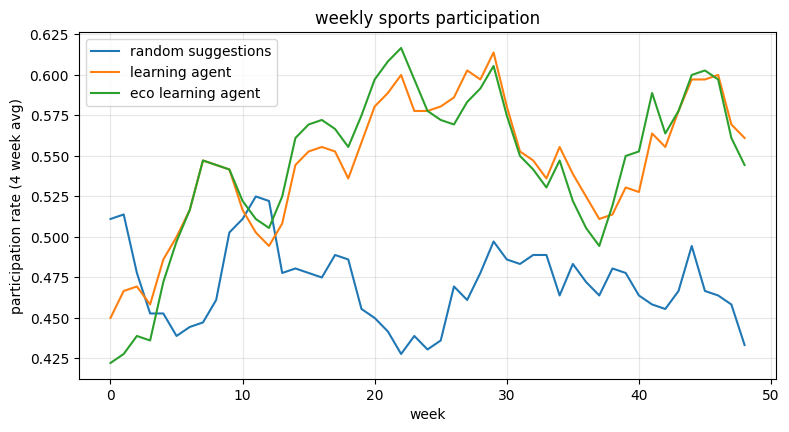

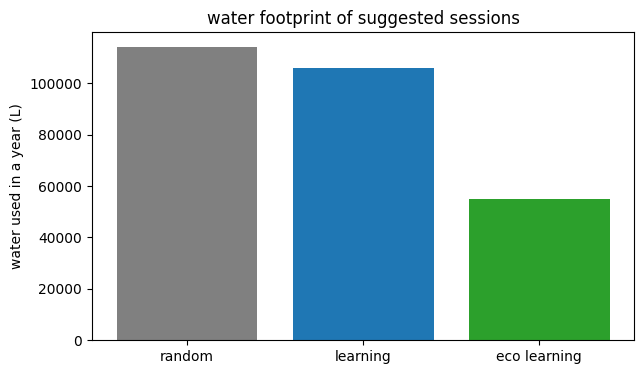

In [25]:
import matplotlib.pyplot as plt

def smooth(x, k=4):
    return np.convolve(x, np.ones(k) / k, mode="valid")

plt.figure(figsize=(9, 4.5))
plt.plot(smooth(rate_rand), label="random suggestions")
plt.plot(smooth(rate_plain), label="learning agent")
plt.plot(smooth(rate_eco), label="eco learning agent")
plt.xlabel("week")
plt.ylabel("participation rate (4 week avg)")
plt.title("weekly sports participation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
names = ["random", "learning", "eco learning"]
plt.bar(names, [water_rand, water_plain, water_eco], color=["gray", "tab:blue", "tab:green"])
plt.ylabel("water used in a year (L)")
plt.title("water footprint of suggested sessions")
plt.show()

In [26]:
t_agent, _ = measure(lambda: run(SportsLearningAgent(eco_weight=0.6)), repeats=3)
print("compute footprint of running the agent for a full year of suggestions:")
_ = report("eco agent", t_agent)

compute footprint of running the agent for a full year of suggestions:
eco agent, runtime=12.401 ms | energy=5.787e-08 kWh | water=0.0002 mL | CO2=0.0204 mg


### **summary**

| agent | type | eco technique | saving vs baseline |
|---|---|---|---|
| A crowd monitor | simple reflex | O(n) grid density + half frame rate, edge only | ~97% less compute energy, CO2 and water, same detections, 0 false alarms |
| B patient care | utility-based | CO2 term in the utility function | 51.2 -> 4.7 Wh per round (~91% less), stress reduction almost the same (33.40 vs 33.05) |
| C school van | goal-based | shortest safe route by uniform cost search | 24.0 -> 11.9 km per trip, ~1.1 t CO2 and 726 L water saved per van per year |
| D sports | learning | resource cost inside the critic's reward | ~48% less water and ~49% less CO2, same participation (~56%) |

runtime based numbers (A) change a little on every run since they depend on the machine.